<a href="https://colab.research.google.com/github/sri4022220/ML-on-Big-Data_Assignment/blob/main/Week5_bankdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install pyspark


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Logistic Regression") \
    .getOrCreate()

In [8]:
import pandas as pd
# Read Excel using pandas first
pdf = pd.read_excel('/content/bank.xlsx')
# Convert pandas DataFrame to Spark DataFrame
dff = spark.createDataFrame(pdf)
display(dff.limit(5))

DataFrame[age: bigint, job: string, marital: string, education: string, default: string, balance: bigint, housing: string, loan: string, contact: string, day: bigint, month: string, duration: bigint, campaign: bigint, pdays: bigint, previous: bigint, poutcome: string, deposit: string]

In [9]:
print(dff.count())

11162


In [10]:
dff.select("deposit").distinct().show()
dff.printSchema()

+-------+
|deposit|
+-------+
|    yes|
|     no|
+-------+

root
 |-- age: long (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: long (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: long (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: long (nullable = true)
 |-- campaign: long (nullable = true)
 |-- pdays: long (nullable = true)
 |-- previous: long (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [11]:
print("yes",dff.select("deposit").where("deposit=='yes'").count())
print("No",dff.select("deposit").where("deposit=='no'").count())

yes 5289
No 5873


In [12]:
# checking the distinct values in string columns of the dataframe using functional programming
[print("column name",dff[t[0]].name,dff.select(t[0]).distinct().show()) for t in dff.dtypes if t[1]=='string' ]

+-------------+
|          job|
+-------------+
|   management|
|      retired|
|      unknown|
|self-employed|
|      student|
|  blue-collar|
| entrepreneur|
|       admin.|
|   technician|
|     services|
|    housemaid|
|   unemployed|
+-------------+

column name <bound method Column.name of Column<'job'>> None
+--------+
| marital|
+--------+
|divorced|
| married|
|  single|
+--------+

column name <bound method Column.name of Column<'marital'>> None
+---------+
|education|
+---------+
|  unknown|
| tertiary|
|secondary|
|  primary|
+---------+

column name <bound method Column.name of Column<'education'>> None
+-------+
|default|
+-------+
|     no|
|    yes|
+-------+

column name <bound method Column.name of Column<'default'>> None
+-------+
|housing|
+-------+
|     no|
|    yes|
+-------+

column name <bound method Column.name of Column<'housing'>> None
+----+
|loan|
+----+
|  no|
| yes|
+----+

column name <bound method Column.name of Column<'loan'>> None
+---------+
|  con

[None, None, None, None, None, None, None, None, None, None]

In [13]:
# taking only integer features
numeric_features = [t[0] for t in dff.dtypes if t[1] == 'int']
dff.select(numeric_features).describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max


In [14]:
#find out is there any null value in any column
print("total records:",dff.count())
[print(col,"Total null values",dff.where(dff[col].isNull()).count()) for col in dff.columns]

total records: 11162
age Total null values 0
job Total null values 0
marital Total null values 0
education Total null values 0
default Total null values 0
balance Total null values 0
housing Total null values 0
loan Total null values 0
contact Total null values 0
day Total null values 0
month Total null values 0
duration Total null values 0
campaign Total null values 0
pdays Total null values 0
previous Total null values 0
poutcome Total null values 0
deposit Total null values 0


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [15]:
# Non Numeric features
df = dff.select('job', 'marital', 'education', 'default',  'housing', 'loan', 'contact', 'duration',  'poutcome', 'deposit')
cols = df.columns
df.printSchema()


root
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- duration: long (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [16]:
df = dff.select('age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit')
cols = df.columns
df.printSchema()

root
 |-- age: long (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: long (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- duration: long (nullable = true)
 |-- campaign: long (nullable = true)
 |-- pdays: long (nullable = true)
 |-- previous: long (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [17]:
# Now we will apply string indexing to categorial variables using pipe line
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
categoricalColumns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
stages = []
for categoricalCol in categoricalColumns:
    stringIndexer = StringIndexer(inputCol = categoricalCol, outputCol = categoricalCol + 'Index')
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "classVec"])
    print(stringIndexer.getOutputCol())
    stages += [stringIndexer, encoder]
label_stringIdx = StringIndexer(inputCol = 'deposit', outputCol = 'label')
print(label_stringIdx)
stages += [label_stringIdx]
numericCols = ['age','balance', 'duration', 'campaign', 'pdays', 'previous']
assemblerInputs = [c + "classVec" for c in categoricalColumns] + numericCols
print(assemblerInputs)
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

jobIndex
maritalIndex
educationIndex
defaultIndex
housingIndex
loanIndex
contactIndex
poutcomeIndex
StringIndexer_05b73f7c658d
['jobclassVec', 'maritalclassVec', 'educationclassVec', 'defaultclassVec', 'housingclassVec', 'loanclassVec', 'contactclassVec', 'poutcomeclassVec', 'age', 'balance', 'duration', 'campaign', 'pdays', 'previous']


In [18]:
from pyspark.ml import Pipeline
pipeline = Pipeline(stages = stages)
pipelineModel = pipeline.fit(df)
df = pipelineModel.transform(df)
df.show(12,True)

+---+-----------+--------+---------+-------+-------+-------+----+-------+--------+--------+-----+--------+--------+-------+--------+--------------+------------+---------------+--------------+-----------------+------------+---------------+------------+---------------+---------+-------------+------------+---------------+-------------+----------------+-----+--------------------+
|age|        job| marital|education|default|balance|housing|loan|contact|duration|campaign|pdays|previous|poutcome|deposit|jobIndex|   jobclassVec|maritalIndex|maritalclassVec|educationIndex|educationclassVec|defaultIndex|defaultclassVec|housingIndex|housingclassVec|loanIndex| loanclassVec|contactIndex|contactclassVec|poutcomeIndex|poutcomeclassVec|label|            features|
+---+-----------+--------+---------+-------+-------+-------+----+-------+--------+--------+-----+--------+--------+-------+--------+--------------+------------+---------------+--------------+-----------------+------------+---------------+----

In [19]:
print(df.select("features").show(1))
print(cols)

+--------------------+
|            features|
+--------------------+
|(30,[3,11,13,16,1...|
+--------------------+
only showing top 1 row
None
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [20]:
# feature vector is in features  from assembler.
selectedCols = ['label', 'features'] + cols
dfSelected = df.select(selectedCols)
dfSelected.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)
 |-- age: long (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: long (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- duration: long (nullable = true)
 |-- campaign: long (nullable = true)
 |-- pdays: long (nullable = true)
 |-- previous: long (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [21]:
# this is code for multiple classification using logistic Regression
from pyspark.ml.classification import OneVsRest
from pyspark.ml.classification import LogisticRegression
train, test = dfSelected.randomSplit([0.7, 0.3], seed = 2018)
lr = LogisticRegression(maxIter=100, \

                        featuresCol="features", \

                        labelCol='label')
ovr = OneVsRest(classifier=lr, \
                labelCol='label', \
                featuresCol='features')
#from pyspark.ml import Pipeline
#pipeline_ovr = Pipeline(stages=[vecAssembler, stdScaler, ovr])
#pipelineModel_ovr = pipeline_ovr.fit(trainDF)

ovrModel = ovr.fit(train)
predictionsovr = ovrModel.transform(test)
predictionsovr.show(10)

+-----+--------------------+---+----------+-------+---------+-------+-------+-------+----+---------+--------+--------+-----+--------+--------+-------+--------------------+----------+
|label|            features|age|       job|marital|education|default|balance|housing|loan|  contact|duration|campaign|pdays|previous|poutcome|deposit|       rawPrediction|prediction|
+-----+--------------------+---+----------+-------+---------+-------+-------+-------+----+---------+--------+--------+-----+--------+--------+-------+--------------------+----------+
|  1.0|(30,[0,11,13,16,1...| 27|management|married|secondary|     no|   2071|     no|  no| cellular|     449|       1|   -1|       0| unknown|    yes|[-0.7190031591650...|       1.0|
|  1.0|(30,[0,11,13,16,1...| 45|management|married|secondary|     no|    446|     no|  no| cellular|     304|       3|   -1|       0| unknown|    yes|[0.33317110688554...|       0.0|
|  1.0|(30,[0,11,13,16,1...| 58|management|married|secondary|     no|   -382|     no|

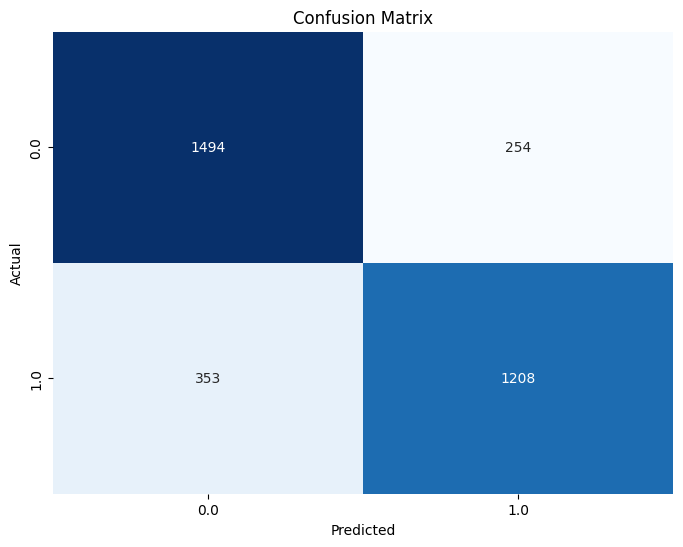

Test accuracy =   0.8165608945300695


In [22]:
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Create MulticlassMetrics object
 #Convert predictions and labels to RDD for MulticlassMetrics
prediction_and_labels = predictionsovr.select("prediction", "label") \
    .withColumnRenamed("indexedLabel", "label") \
    .toPandas()  # Convert to Pandas DataFrame for easier manipulation
# Create a confusion matrix using Pandas
confusion_matrix = pd.crosstab(prediction_and_labels['label'], prediction_and_labels['prediction'], rownames=['Actual'], colnames=['Predicted'])

# Plot the confusion matrix using Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

evaluator = MulticlassClassificationEvaluator(\
labelCol="label", predictionCol="prediction",\
metricName="accuracy")
accuracy = evaluator.evaluate(predictionsovr)
print("Test accuracy =  " , accuracy)

In [24]:
from pyspark.ml.classification import DecisionTreeClassifier
train, test = dfSelected.randomSplit([0.7, 0.3], seed = 2018)
print("Training Dataset Count: " + str(train.count()))
print("Test Dataset Count: " + str(test.count()))
dt = DecisionTreeClassifier(featuresCol = 'features', labelCol = 'label', maxDepth = 3)
dtModel = dt.fit(train)
predictions = dtModel.transform(test)

#predictions.select("label","prediction").show(10)
predictions.select('age', 'job', 'label', 'rawPrediction', 'prediction', 'probability').show(10)
print("Total Actual Positive",predictions.select("label").where('label == 1.0').count())
print("Total Actual Negative",predictions.select("label").where('label == 0.0').count())
pr = predictions.toPandas()
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0

print("Total",len(pr["label"]))
for lbl in range(len(pr["label"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["label"][lbl]:
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["label"][lbl]:
      TrueNegative+=1
    else:
      FalseNegative+=1
print("Total Positive & Negative in Prediction. Pos: ",pos,",Neg",Neg)
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Training Dataset Count: 7853
Test Dataset Count: 3309
+---+----------+-----+---------------+----------+--------------------+
|age|       job|label|  rawPrediction|prediction|         probability|
+---+----------+-----+---------------+----------+--------------------+
| 27|management|  1.0|  [348.0,880.0]|       1.0|[0.28338762214983...|
| 45|management|  1.0|[3334.0,1080.0]|       0.0|[0.75532396918894...|
| 58|management|  1.0| [210.0,1261.0]|       1.0|[0.14276002719238...|
| 59|management|  1.0|[3334.0,1080.0]|       0.0|[0.75532396918894...|
| 46|management|  1.0| [210.0,1261.0]|       1.0|[0.14276002719238...|
| 37|management|  1.0|[3334.0,1080.0]|       0.0|[0.75532396918894...|
| 48|management|  1.0|  [348.0,880.0]|       1.0|[0.28338762214983...|
| 47|management|  1.0|   [170.0,78.0]|       0.0|[0.68548387096774...|
| 49|management|  1.0|[3334.0,1080.0]|       0.0|[0.75532396918894...|
| 40|management|  1.0| [210.0,1261.0]|       1.0|[0.14276002719238...|
+---+----------+-----+-

In [25]:
#predictions.show(10)
#print(dtModel.toDebugString)
#Evaluate our Decision Tree model.

from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator()

print("Test Area Under ROC: " + str(evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})))

Test Area Under ROC: 0.5039567504254886


In [26]:
#RandomForest
from pyspark.ml.classification import RandomForestClassifier
#rf = RandomForestClassifier(featuresCol = 'features', labelCol = 'label')
rf = RandomForestClassifier(featuresCol='features', labelCol='label', maxDepth = 4,numTrees=20)
train, test = dfSelected.randomSplit([0.7, 0.3], seed = 2018)
rfModel = rf.fit(train)
predictions = rfModel.transform(test)
pr = predictions.toPandas()
print("Total Actual Positive",predictions.select("label").where('label == 1.0').count())
print("Total Actual Negative",predictions.select("label").where('label == 0.0').count())

evaluator = BinaryClassificationEvaluator()
print("Test Area Under ROC: " + str(evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})))
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0
print("Total",len(pr["label"]))
for lbl in range(len(pr["label"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["label"][lbl]:
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["label"][lbl]:
      TrueNegative+=1
    else:
      FalseNegative+=1
print("Total positive & Negative in Predictions, Pos",pos,"Neg",Neg)
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Total Actual Positive 1561
Total Actual Negative 1748
Test Area Under ROC: 0.8811061823011415
Total 3309
Total positive & Negative in Predictions, Pos 1491 Neg 1818
TruePostive 1191 FalsePostive 300
TrueNegative 1448 FalseNegative 370


In [27]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier

ml = GBTClassifier(maxIter=10, featuresCol='features', labelCol='label',maxDepth = 10)
train, test = dfSelected.randomSplit([0.7, 0.2], seed = 2018)
mlModel = ml.fit(train)
predictions = mlModel.transform(test)

evaluator = BinaryClassificationEvaluator()
print("Test Area Under ROC: " + str(evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})))

# Calculate accuracy and F-1 score
#accuracy_evaluator = MulticlassClassificationEvaluator(metricName='accuracy')
#accuracy = accuracy_evaluator.evaluate(predictions.select('label', 'prediction'))

#f1_score_evaluator = MulticlassClassificationEvaluator(metricName='f1')
#f1_score = f1_score_evaluator.evaluate(predictions.select('label', 'prediction'))
#print(accuracy, f1_score)

Test Area Under ROC: 0.877632365064902


In [29]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Initialize GBT
gbt = GBTClassifier(featuresCol='features', labelCol='label')

# Reduced grid to speed up execution
paramGrid = (ParamGridBuilder()
             .addGrid(gbt.maxDepth, [2, 5])
             .addGrid(gbt.maxIter, [5, 10])
             .build())

# Using 3-fold cross validation for efficiency
cv = CrossValidator(estimator=gbt,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator,
                    numFolds=3)

print("Starting cross-validation...")
cvModel = cv.fit(train)
predictions = cvModel.transform(test)

final_roc = evaluator.evaluate(predictions)
print(f"Test Area Under ROC after CV: {final_roc}")

Starting cross-validation...
Test Area Under ROC after CV: 0.8975237561205194


In [30]:
predictions.select('label', 'prediction').show(13)

+-----+----------+
|label|prediction|
+-----+----------+
|  1.0|       1.0|
|  1.0|       0.0|
|  1.0|       1.0|
|  1.0|       0.0|
|  1.0|       1.0|
|  1.0|       1.0|
|  1.0|       1.0|
|  1.0|       1.0|
|  1.0|       0.0|
|  1.0|       1.0|
|  1.0|       1.0|
|  1.0|       0.0|
|  1.0|       1.0|
+-----+----------+
only showing top 13 rows
